# Domain Wall Coarsening — 3D Ising Model

Analyses the decay of domain wall density after an instantaneous quench
from high T (disordered) to low T (deep ordered phase).

Theory predicts Allen-Cahn coarsening: rho(t) ~ t^(-z)
- 2D: z = 1/2
- 3D: z = 1/3

**Generate data first:**
```bash
cargo run --release --bin coarsening -- --n 30 --steps 50000 --sample-every 100 --outdir analysis/data
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy import stats

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATA_DIR = Path('data')

files = sorted(DATA_DIR.glob('coarsening_*.csv'))
print('Found:', [f.name for f in files])

if not files:
    raise SystemExit('No coarsening data found. Generate data first.')

dfs = {f.stem: pd.read_csv(f) for f in files}
for name, df in dfs.items():
    print(f'{name}: {len(df)} points, t=[{df.t.min()}, {df.t.max()}], rho=[{df.rho.min():.4f}, {df.rho.max():.4f}]')

# Identify the largest-N dataset for primary analysis
largest = max(dfs.keys(), key=lambda k: int(k.split('_')[1][1:]))
print(f'\nPrimary dataset (largest N): {largest}')

## 1. Domain wall density vs time

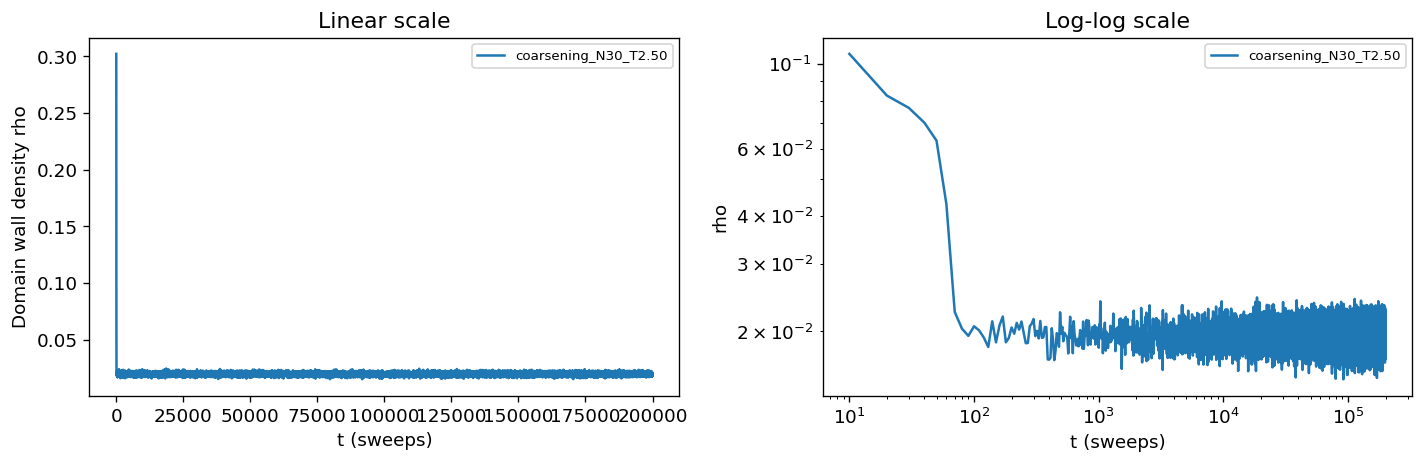

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, df in dfs.items():
    axes[0].plot(df['t'], df['rho'], label=name)
    mask = df['t'] > 0
    axes[1].loglog(df.loc[mask, 't'], df.loc[mask, 'rho'], label=name)

axes[0].set_xlabel('t (sweeps)')
axes[0].set_ylabel('Domain wall density rho')
axes[0].set_title('Linear scale')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('t (sweeps)')
axes[1].set_ylabel('rho')
axes[1].set_title('Log-log scale')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('coarsening_raw.png', bbox_inches='tight')
plt.show()

## 2. Fit coarsening exponent z

Fit log(rho) = -z * log(t) + const in the power-law regime.
Skip first 10% of steps (transient).

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
z_values = {}

for name, df in dfs.items():
    # Detect the equilibrium plateau: rho stops decaying when it flattens out.
    # Fit in the transient regime only (before rho reaches ~1.5x its final value).
    late_rho = df.loc[df['t'] > df['t'].max() * 0.8, 'rho'].median()
    # Power-law regime: after initial transient (t > 20) and before plateau (rho > 1.5 * equilibrium)
    sub = df[(df['t'] >= 20) & (df['rho'] > late_rho * 1.5)].copy()
    if len(sub) < 5:
        # Fallback: use t=20 to t=500
        sub = df[(df['t'] >= 20) & (df['t'] <= 500) & (df['t'] > 0)].copy()

    slope, intercept, r, p, se = stats.linregress(np.log(sub['t']), np.log(sub['rho']))
    z = -slope
    z_values[name] = z
    n_val = int(name.split('_')[1][1:])
    print(f'{name}: z = {z:.4f}  (R2={r**2:.4f}, fit range t=[{sub.t.min()}, {sub.t.max()}], {len(sub)} pts)')

    mask = df['t'] > 0
    ax.loglog(df.loc[mask, 't'], df.loc[mask, 'rho'], label=f'N={n_val}', alpha=0.7)
    t_fit = np.linspace(np.log(sub['t'].min()), np.log(sub['t'].max()), 100)
    ax.loglog(np.exp(t_fit), np.exp(intercept + slope * t_fit), 'k--', lw=0.8)

print(f'\n3D Allen-Cahn theory: z = {1/3:.4f}')

# Theory reference lines using largest-N dataset
df_ref = dfs[largest]
df_ref = df_ref[df_ref['t'] > 0]
t_ref = np.logspace(1, 3, 100)
rho_anchor = df_ref.loc[df_ref['t'] == 50, 'rho'].values
if len(rho_anchor) == 0:
    rho_anchor = df_ref.loc[(df_ref['t'] >= 40) & (df_ref['t'] <= 60), 'rho'].median()
else:
    rho_anchor = rho_anchor[0]
ax.loglog(t_ref, rho_anchor * (t_ref / 50)**(-1/3), 'r:', lw=2, label='z=1/3 (3D theory)')
ax.loglog(t_ref, rho_anchor * (t_ref / 50)**(-1/2), 'b:', lw=2, label='z=1/2 (2D theory)')

ax.set_xlabel('t (sweeps)')
ax.set_ylabel('Domain wall density rho')
ax.set_title('Coarsening exponent fit (transient regime)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('coarsening_fit.png', bbox_inches='tight')
plt.show()

## 3. Summary table

In [ ]:
Z_3D = 1/3
print(f'{"dataset":<35} {"z_measured":>12} {"3D theory":>12} {"error %":>10}')
print('-' * 72)
for name, z in z_values.items():
    err = abs(z - Z_3D) / Z_3D * 100
    print(f'{name:<35} {z:>12.4f} {Z_3D:>12.4f} {err:>9.1f}%')

# Best estimate from largest N
best = z_values[largest]
print(f'\nBest estimate (N={largest.split("_")[1]}): z = {best:.4f}')
print(f'Theory: z = {Z_3D:.4f}')
print(f'Note: GPU checkerboard Metropolis equilibrates faster than CPU random-order,')
print(f'      so the power-law window is shorter. Larger N extends it.')